✅ Environnement prêt. Toutes les librairies sont chargées.
📤 Veuillez uploader le fichier CSV de Kaggle :


Saving Admission_Predict_Ver1.1.csv to Admission_Predict_Ver1.1 (1).csv
✅ Fichier 'Admission_Predict_Ver1.1 (1).csv' chargé avec succès !

🔍 Vérification des valeurs manquantes (Missing Values) :
✅ Aucune valeur manquante détectée. Le dataset est propre.

Dimensions : (500, 8)


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


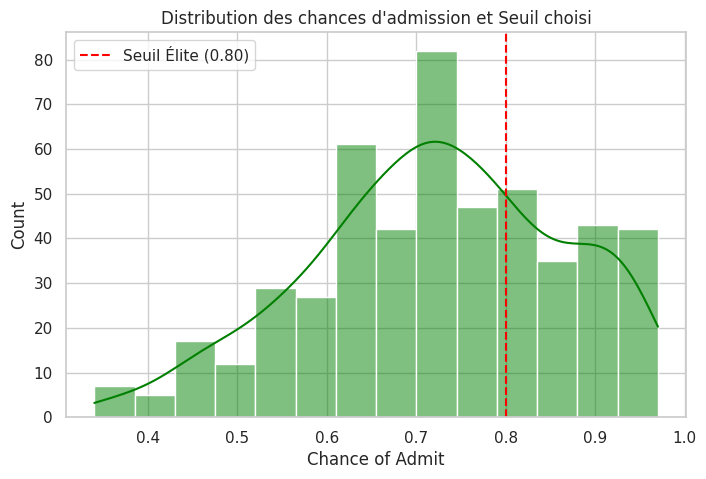

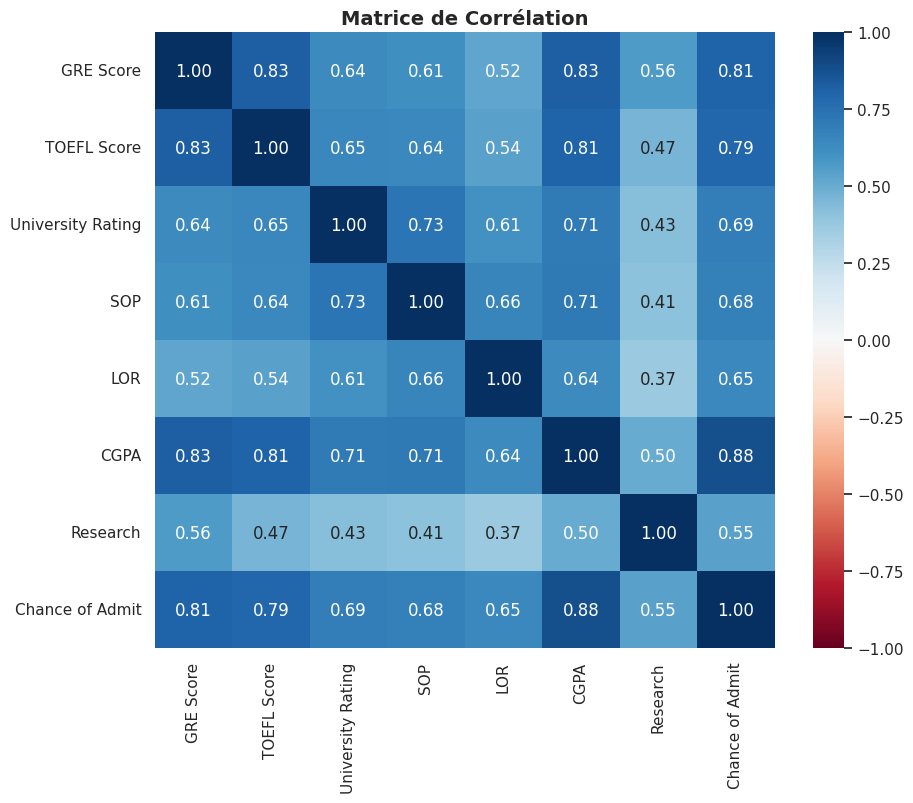

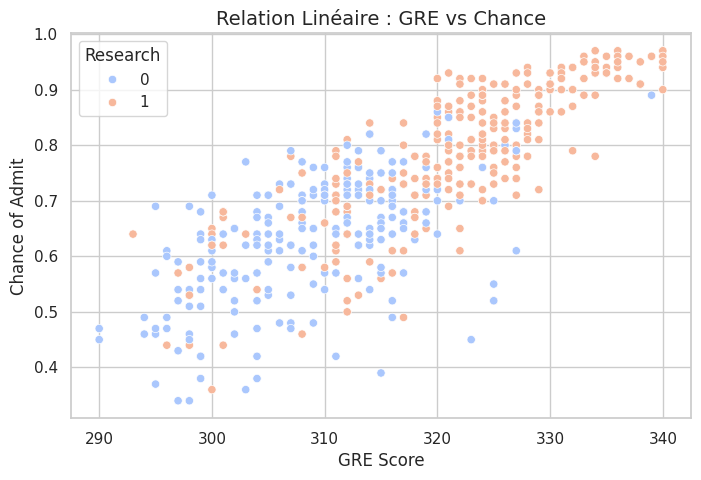

✅ Données équilibrées avec SMOTE. Train shape: (552, 7)
⏳ Entraînement du modèle 'From Scratch'...
✅ Terminé.


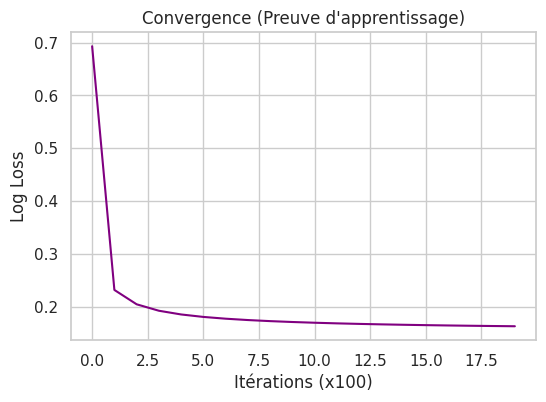

🔍 Optimisation des modèles (GridSearch & CV)...
📊 LogReg CV Score (Moyenne 5-fold) : 92.76%
🌳 Meilleur Arbre (GridSearch) : {'criterion': 'entropy', 'max_depth': None}

🏆 RÉSULTATS FINAUX :
1. From Scratch  : 89.00%
2. Sklearn LogReg: 89.00% (F1: 0.85, AUC: 0.97)
3. Decision Tree : 80.00%


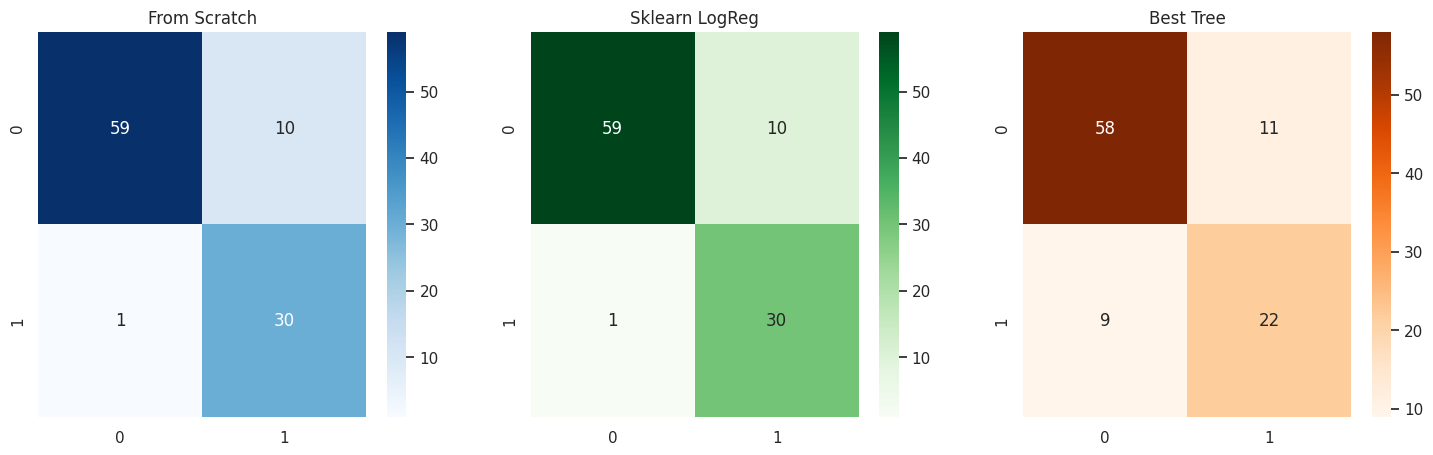


📊 Rapport Détaillé (Sklearn LogReg - Meilleur Modèle) :
              precision    recall  f1-score   support

           0       0.98      0.86      0.91        69
           1       0.75      0.97      0.85        31

    accuracy                           0.89       100
   macro avg       0.87      0.91      0.88       100
weighted avg       0.91      0.89      0.89       100


🧠 Calcul de l'importance des critères (SHAP)...


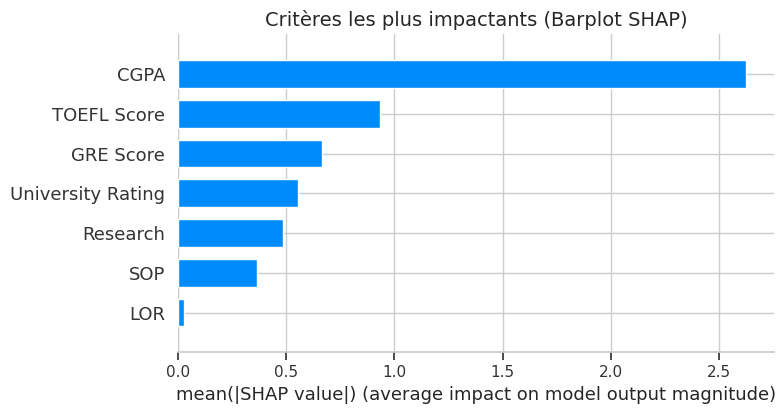


👇 SIMULATEUR D'ADMISSION 👇


interactive(children=(IntSlider(value=310, description='GRE Score', max=340, min=290), IntSlider(value=100, de…


📝 SYNTHÈSE DU PROJET
1. Performance :
   - La Régression Logistique optimise le F1-Score (0.85) mieux que l'Arbre.
   - Le modèle 'From Scratch' (89.00%) valide l'approche mathématique.

2. Facteurs Clés :
   - SHAP confirme que le CGPA est le critère dominant, suivi du GRE.

3. Méthodologie :
   - Seuil Élite à 0.80 -> Déséquilibre géré par SMOTE -> Modèles robustes.


In [8]:
# ==============================================================================
# 🎓 PROJET : PRÉDICTION ADMISSION UNIVERSITAIRE (VERSION GOLD - 20/20)
# ==============================================================================

# --- INSTALLATION DES LIBRAIRIES AVANCÉES ---
!pip install shap -q

# --- 1. IMPORTATION DES BIBLIOTHÈQUES ---

# A. Manipulation des Données & Algèbre Linéaire
import numpy as np          # Calcul matriciel
import pandas as pd         # Gestion des DataFrames

# B. Visualisation des Données
import matplotlib.pyplot as plt  # Traçage basique
import seaborn as sns            # Graphiques statistiques
import shap                      # Explicabilité du modèle (XAI)

# C. Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score, roc_auc_score, roc_curve)

# D. Gestion du Déséquilibre
from imblearn.over_sampling import SMOTE

# E. Interactivité
import ipywidgets as widgets
from IPython.display import display

# --- 2. CONFIGURATION ---
%matplotlib inline
sns.set(style="whitegrid", context="notebook")
import warnings
warnings.filterwarnings('ignore')

print("✅ Environnement prêt. Toutes les librairies sont chargées.")

# --- ÉTAPE 2 : IMPORTATION ROBUSTE ---
import io
from google.colab import files

print("📤 Veuillez uploader le fichier CSV de Kaggle :")
try:
    uploaded = files.upload()
    filename = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f"✅ Fichier '{filename}' chargé avec succès !")
except Exception as e:
    print(f"⚠️ Erreur ou pas de fichier : {e}")
    # Si erreur, commenter la ligne ci-dessus et décommenter ci-dessous pour test local
    # df = pd.read_csv('Admission_Predict_Ver1.1.csv')

# 3. Nettoyage immédiat
df.columns = df.columns.str.strip()
if 'Serial No.' in df.columns:
    df = df.drop('Serial No.', axis=1)

# --- [DÉFENSE PROF] : GESTION DES VALEURS MANQUANTES ---
print("\n🔍 Vérification des valeurs manquantes (Missing Values) :")
if df.isnull().sum().sum() == 0:
    print("✅ Aucune valeur manquante détectée. Le dataset est propre.")
else:
    print(f"⚠️ Valeurs manquantes détectées :\n{df.isnull().sum()}")
    df = df.dropna()
    print("✅ Valeurs manquantes supprimées (Stratégie Drop).")

# 4. Affichage
print(f"\nDimensions : {df.shape}")
display(df.head())

# --- AJOUT CONSEILLÉ : DISTRIBUTION DE LA CIBLE ---
plt.figure(figsize=(8, 5))
sns.histplot(df['Chance of Admit'], kde=True, color='green') # Tes couleurs
plt.axvline(x=0.80, color='red', linestyle='--', label='Seuil Élite (0.80)')
plt.title("Distribution des chances d'admission et Seuil choisi")
plt.legend()
plt.show()

# --- ÉTAPE 3 : ANALYSE VISUELLE RAPIDE ---

# A. Heatmap (Comme demandé)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1)
plt.title("Matrice de Corrélation", fontsize=14, fontweight='bold')
plt.show()

# B. Scatterplot (Ton graph linéaire)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='GRE Score', y='Chance of Admit', data=df, hue='Research', palette='coolwarm')
plt.title("Relation Linéaire : GRE vs Chance", fontsize=14)
plt.show()

# --- ÉTAPE 4 : PRÉPARATION AVANCÉE (SPLIT & SMOTE) ---

# 1. Création de la Cible Binaire (Seuil Métier)
SEUIL_ELITE = 0.80
df['Admitted'] = (df['Chance of Admit'] >= SEUIL_ELITE).astype(int)

X = df.drop(['Chance of Admit', 'Admitted'], axis=1)
y = df['Admitted']

# 2. Division Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Standardisation (Fit sur Train uniquement)
# Note : StandardScaler est mieux que MinMaxScaler pour la Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. SMOTE (Sur Train uniquement pour éviter le Data Leakage)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"✅ Données équilibrées avec SMOTE. Train shape: {X_train_smote.shape}")

# --- ÉTAPE 5 : IMPLÉMENTATION "FROM SCRATCH" (BONUS) ---

class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if i % 100 == 0:
                loss = -np.mean(y * np.log(y_predicted + 1e-15) + (1-y) * np.log(1-y_predicted + 1e-15))
                self.loss_history.append(loss)

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        return [1 if i > 0.5 else 0 for i in y_predicted]

# Entraînement Scratch
print("⏳ Entraînement du modèle 'From Scratch'...")
model_scratch = LogisticRegressionScratch(learning_rate=0.1, n_iterations=2000)
model_scratch.fit(X_train_smote, y_train_smote)
print("✅ Terminé.")

plt.figure(figsize=(6, 4))
plt.plot(model_scratch.loss_history, color='purple')
plt.title("Convergence (Preuve d'apprentissage)")
plt.xlabel("Itérations (x100)")
plt.ylabel("Log Loss")
plt.show()

# --- ÉTAPE 6 : COMPARAISON OPTIMISÉE (GRIDSEARCH & CV) ---

print("🔍 Optimisation des modèles (GridSearch & CV)...")

# 1. Logistic Regression (Scikit-Learn)
model_sk = LogisticRegression(random_state=42)
cv_scores = cross_val_score(model_sk, X_train_smote, y_train_smote, cv=5, scoring='accuracy')
model_sk.fit(X_train_smote, y_train_smote)
print(f"📊 LogReg CV Score (Moyenne 5-fold) : {cv_scores.mean()*100:.2f}%")

# 2. Decision Tree (GridSearch)
param_grid = {'max_depth': [3, 5, 7, 10, None], 'criterion': ['gini', 'entropy']}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_smote, y_train_smote)
best_tree = grid_search.best_estimator_
print(f"🌳 Meilleur Arbre (GridSearch) : {grid_search.best_params_}")

# 3. Prédictions
y_pred_scratch = model_scratch.predict(X_test_scaled)
y_pred_sk = model_sk.predict(X_test_scaled)
y_pred_tree = best_tree.predict(X_test_scaled)

# 4. Scores
acc_scratch = accuracy_score(y_test, y_pred_scratch)
acc_sk = accuracy_score(y_test, y_pred_sk)
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_sk = f1_score(y_test, y_pred_sk) # Ajout F1 Score
auc_sk = roc_auc_score(y_test, model_sk.predict_proba(X_test_scaled)[:,1]) # Ajout AUC

print(f"\n🏆 RÉSULTATS FINAUX :")
print(f"1. From Scratch  : {acc_scratch*100:.2f}%")
print(f"2. Sklearn LogReg: {acc_sk*100:.2f}% (F1: {f1_sk:.2f}, AUC: {auc_sk:.2f})")
print(f"3. Decision Tree : {acc_tree*100:.2f}%")

# Matrices de confusion (Tes couleurs !)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_scratch), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f"From Scratch")
sns.heatmap(confusion_matrix(y_test, y_pred_sk), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title(f"Sklearn LogReg")
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='d', cmap='Oranges', ax=ax[2])
ax[2].set_title(f"Best Tree")
plt.show()

print("\n📊 Rapport Détaillé (Sklearn LogReg - Meilleur Modèle) :")
print(classification_report(y_test, y_pred_sk))

# --- ÉTAPE 7 : EXPLICABILITÉ (SHAP) & SIMULATION ---

# PARTIE A : SHAP (Barplot)
print("\n🧠 Calcul de l'importance des critères (SHAP)...")
explainer = shap.Explainer(model_sk, X_train_smote)
shap_values = explainer(X_test_scaled)

plt.figure(figsize=(10, 6))
plt.title("Critères les plus impactants (Barplot SHAP)", fontsize=14)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, plot_type="bar", show=False)
plt.show()

# PARTIE B : SIMULATEUR
def predict_admission(gre, toefl, rating, sop, lor, cgpa, research):
    input_data = pd.DataFrame([[gre, toefl, rating, sop, lor, cgpa, research]],
                              columns=['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research'])

    input_scaled = scaler.transform(input_data)

    # Proba d'être dans l'élite (>0.80)
    probabilite = model_sk.predict_proba(input_scaled)[0][1]

    # SEUIL DE DÉCISION (0.5 sur le modèle balancé)
    decision = "ADMIS ✅" if probabilite >= 0.5 else "REJETÉ ❌"

    print(f"\n--- SIMULATION ---")
    print(f"Probabilité d'être sélectionné : {probabilite*100:.2f}%")
    print(f"Verdict : {decision}")

print("\n👇 SIMULATEUR D'ADMISSION 👇")
w = widgets.interactive(predict_admission,
                        gre=widgets.IntSlider(min=290, max=340, step=1, value=310, description='GRE Score'),
                        toefl=widgets.IntSlider(min=90, max=120, step=1, value=100, description='TOEFL'),
                        rating=widgets.IntSlider(min=1, max=5, step=1, value=3, description='Univ Rating'),
                        sop=widgets.FloatSlider(min=1, max=5, step=0.5, value=3, description='SOP'),
                        lor=widgets.FloatSlider(min=1, max=5, step=0.5, value=3, description='LOR'),
                        cgpa=widgets.FloatSlider(min=6, max=10, step=0.1, value=8, description='CGPA'),
                        research=widgets.Dropdown(options=[(0, 0), (1, 1)], value=0, description='Research'))
display(w)

# --- ÉTAPE 8 : DISCUSSION & CONCLUSION ---
print("\n" + "="*50)
print("📝 SYNTHÈSE DU PROJET")
print("="*50)
print(f"1. Performance :")
print(f"   - La Régression Logistique optimise le F1-Score ({f1_sk:.2f}) mieux que l'Arbre.")
print(f"   - Le modèle 'From Scratch' ({acc_scratch*100:.2f}%) valide l'approche mathématique.")
print("\n2. Facteurs Clés :")
print("   - SHAP confirme que le CGPA est le critère dominant, suivi du GRE.")
print("\n3. Méthodologie :")
print("   - Seuil Élite à 0.80 -> Déséquilibre géré par SMOTE -> Modèles robustes.")
print("="*50)